# E-Commerce Customer Churn Prediction
## Exploratory Data Analysis (EDA)

This notebook explores the dataset to understand customer behavior and identify patterns related to churn.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline

# Clean plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

## 2. Load Dataset

In [3]:
df = pd.read_excel('../data/E Commerce Dataset.xlsx', sheet_name='E Comm')

print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Rows: 5630, Columns: 20


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
print('Column Names:')
print(df.columns.tolist())

Column Names:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [5]:
print('Data Types:')
print(df.dtypes)

Data Types:
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


## 3. Basic Dataset Information

In [6]:
print('Missing Values per Column:')
print(df.isnull().sum())

Missing Values per Column:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [7]:
print(f'Duplicate Rows: {df.duplicated().sum()}')

Duplicate Rows: 0


In [8]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


## 4. Churn Distribution

In [9]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Churn Count:')
print(churn_counts)
print('\nChurn Percentage:')
print(churn_pct.round(2))

Churn Count:
Churn
0    4682
1     948
Name: count, dtype: int64

Churn Percentage:
Churn
0    83.16
1    16.84
Name: proportion, dtype: float64


C:\Users\paras\AppData\Local\Temp\ipykernel_4300\4201748072.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'tomato'])


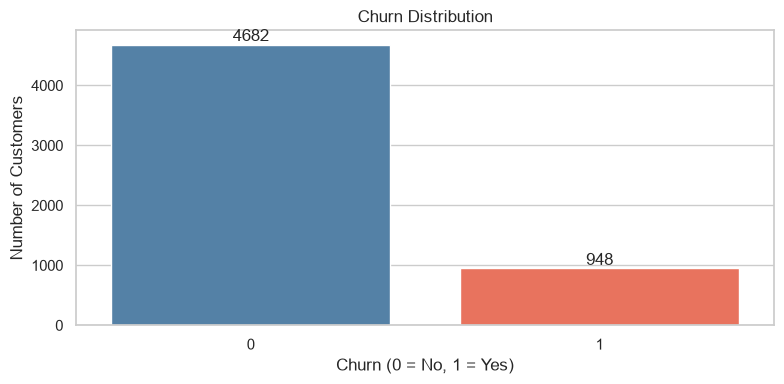

In [10]:
ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'tomato'])
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn (0 = No, 1 = Yes)')
ax.set_ylabel('Number of Customers')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced — most customers (≈83%) did not churn, while only ≈17% churned. This is typical in real-world churn datasets.

## 5. Numerical Feature Analysis

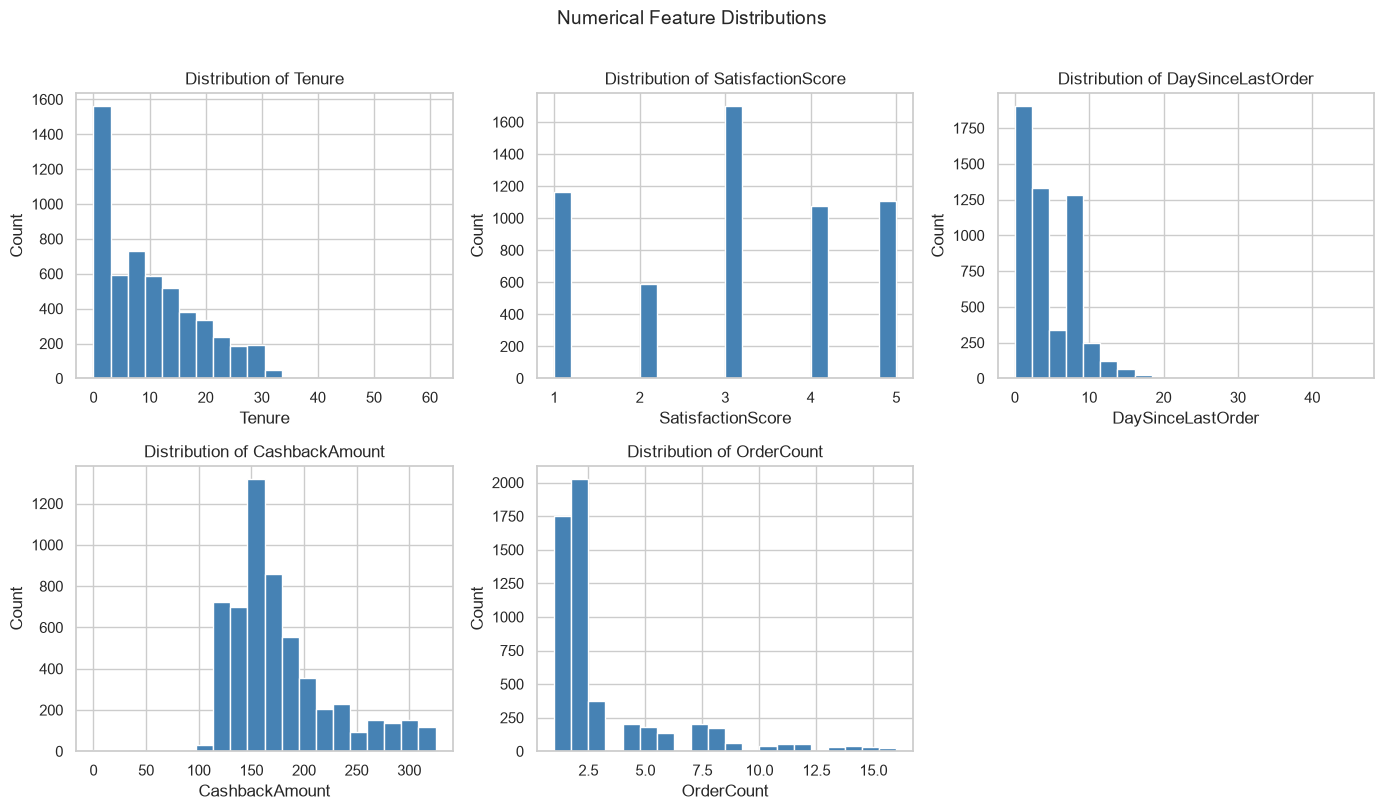

In [11]:
num_cols = ['Tenure', 'SatisfactionScore', 'DaySinceLastOrder', 'CashbackAmount', 'OrderCount']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Tenure is right-skewed — many customers are relatively new. CashbackAmount shows a wide spread. SatisfactionScore is fairly evenly distributed across 1–5.

## 6. Categorical Feature Analysis

C:\Users\paras\AppData\Local\Temp\ipykernel_4300\2794074293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
C:\Users\paras\AppData\Local\Temp\ipykernel_4300\2794074293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
C:\Users\paras\AppData\Local\Temp\ipykernel_4300\2794074293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
C:\Users\paras\AppData\Local\Temp\ipykernel_4300\2794074293.py:7: FutureW

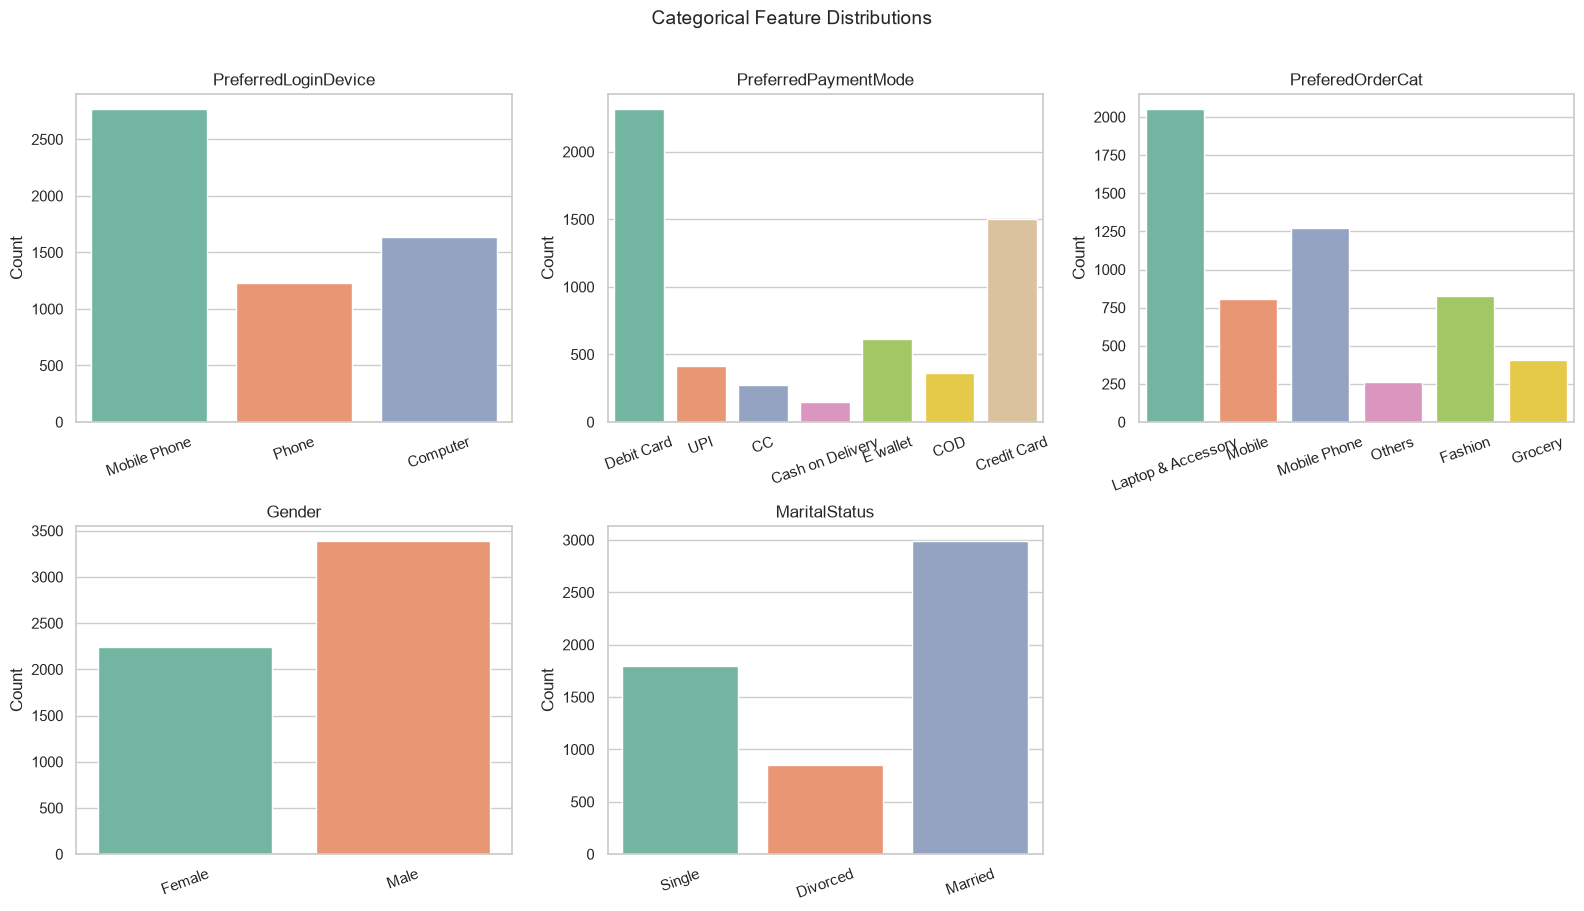

In [12]:
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'Gender', 'MaritalStatus']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)

axes[5].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation:** Mobile Phone is the most common login device. Debit Card and UPI are the most preferred payment modes. Mobile and Laptop & Accessory dominate the preferred order categories.

## 7. Churn vs Important Features

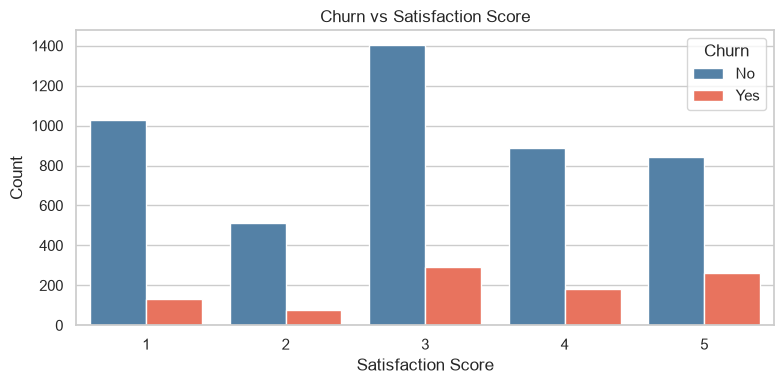

In [13]:
# Churn vs SatisfactionScore
ax = sns.countplot(x='SatisfactionScore', hue='Churn', data=df, palette=['steelblue', 'tomato'])
ax.set_title('Churn vs Satisfaction Score')
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Count')
ax.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

**Observation:** Customers with lower satisfaction scores do not necessarily churn more — churn is spread across all satisfaction levels, suggesting other factors also play a role.

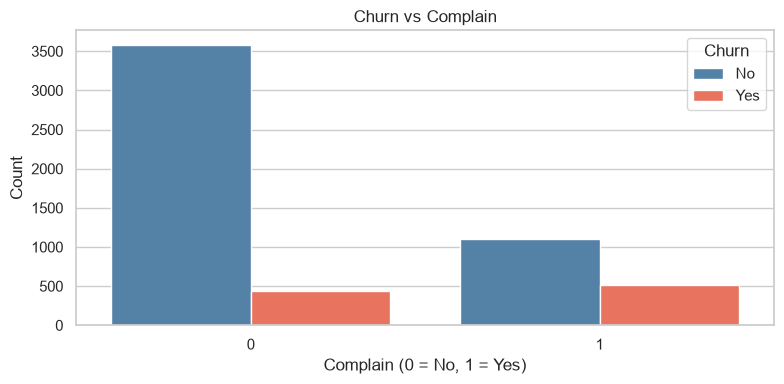

In [14]:
# Churn vs Complain
ax = sns.countplot(x='Complain', hue='Churn', data=df, palette=['steelblue', 'tomato'])
ax.set_title('Churn vs Complain')
ax.set_xlabel('Complain (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
ax.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

**Observation:** Customers who raised a complaint have a noticeably higher churn rate. This makes Complain one of the strongest churn indicators in the dataset.

C:\Users\paras\AppData\Local\Temp\ipykernel_4300\1995271593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Churn', y='Tenure', data=df, palette=['steelblue', 'tomato'])


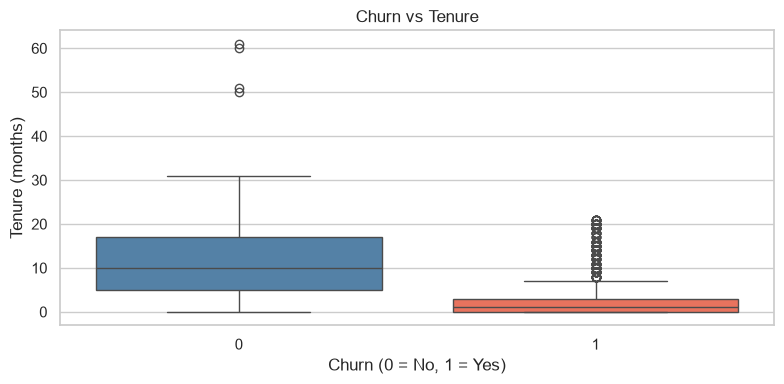

In [15]:
# Churn vs Tenure
ax = sns.boxplot(x='Churn', y='Tenure', data=df, palette=['steelblue', 'tomato'])
ax.set_title('Churn vs Tenure')
ax.set_xlabel('Churn (0 = No, 1 = Yes)')
ax.set_ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

**Observation:** Churned customers tend to have lower tenure, meaning newer customers are more likely to leave. Long-term customers are more loyal.

C:\Users\paras\AppData\Local\Temp\ipykernel_4300\153326735.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Churn', y='DaySinceLastOrder', data=df, palette=['steelblue', 'tomato'])


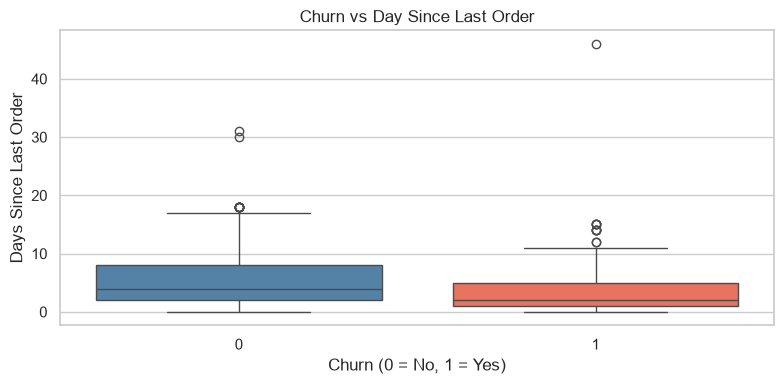

In [16]:
# Churn vs DaySinceLastOrder
ax = sns.boxplot(x='Churn', y='DaySinceLastOrder', data=df, palette=['steelblue', 'tomato'])
ax.set_title('Churn vs Day Since Last Order')
ax.set_xlabel('Churn (0 = No, 1 = Yes)')
ax.set_ylabel('Days Since Last Order')
plt.tight_layout()
plt.show()

**Observation:** The distribution of days since last order is similar for both churned and non-churned customers, suggesting this feature alone is not a strong predictor.

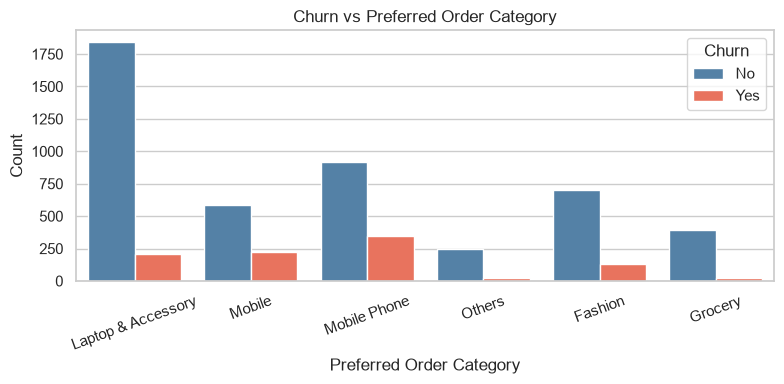

In [17]:
# Churn vs PreferedOrderCat
ax = sns.countplot(x='PreferedOrderCat', hue='Churn', data=df, palette=['steelblue', 'tomato'])
ax.set_title('Churn vs Preferred Order Category')
ax.set_xlabel('Preferred Order Category')
ax.set_ylabel('Count')
ax.legend(title='Churn', labels=['No', 'Yes'])
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Observation:** Mobile Phone category shows a relatively higher proportion of churned customers compared to other categories like Grocery or Fashion.

## 8. Correlation Analysis

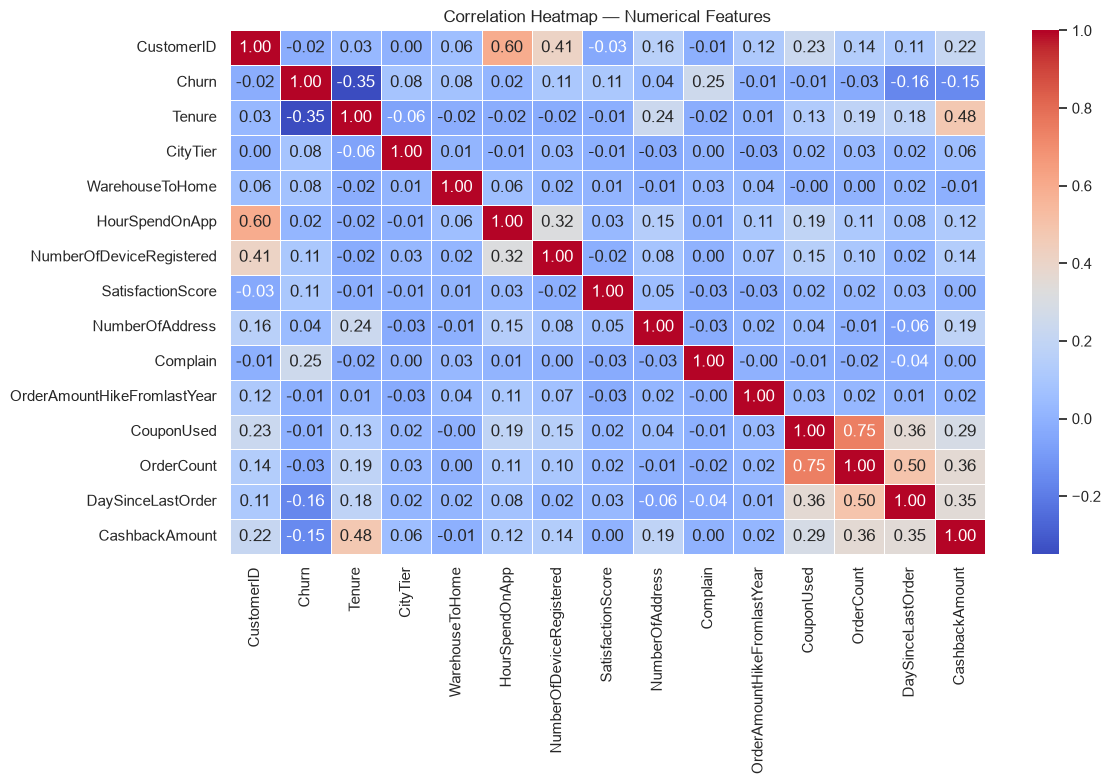

In [18]:
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(
    num_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

**Observation:** `Complain` shows a positive correlation with `Churn`. `Tenure` shows a negative correlation with `Churn` — longer-tenured customers are less likely to churn. `CouponUsed` and `OrderCount` are positively correlated with each other, which makes sense as more orders lead to more coupon usage.

## 9. Key Findings

Based on the EDA performed on the E-Commerce Customer Churn dataset:

1. **Class Imbalance:** About 83% of customers did not churn and 17% churned. The dataset is imbalanced.

2. **Complain is a strong churn signal:** Customers who raised a complaint are significantly more likely to churn.

3. **Tenure matters:** Customers with lower tenure (newer customers) churn more. Long-term customers tend to stay.

4. **Mobile Phone category has higher churn:** Customers who prefer ordering Mobile Phones show a higher churn proportion compared to other categories.

5. **Missing values exist:** Columns like Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, and DaySinceLastOrder have missing values — handled using median imputation in `train.py`.

6. **No duplicate rows** were found in the dataset.

7. **SatisfactionScore alone is not decisive:** Churn is spread across all satisfaction levels, meaning it is not the only factor driving churn.

8. **Mobile Phone is the most common login device** and Debit Card / UPI are the most preferred payment modes.